In [6]:
# 분류, 회귀

# 의사결정트리 (스케일이 필요없음) => 트라가 1개
# -------------------------------------------------------------------
# 랜덤포레스트 => 트리를 여러개 병렬로 학습 후 평균
# -------------------------------------------------------------------
# XGBoost => 트리가 여러개 순차적으로 1개씩 추가하면서 보정
# LightGBM => 트리가 여러개 효율적인 노드만 순차적으로 추가 보정(속도가 빠름)

In [7]:
import pandas as pd
df = pd.read_csv("http://114.207.245.181:13000/csv/UniversalBank01.csv")
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,PersonalLoan,SecuritiesAccount,CDAccount,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [8]:
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'PersonalLoan', 'SecuritiesAccount',
       'CDAccount', 'Online', 'CreditCard'],
      dtype='object')

In [9]:
t1 = {'ID':'고객아이디', 'Age':'나이', 'Experience':'경력', 'Income':'연소득',
      'ZIP Code':'우편번호', 'Family':'가족수', 'CCAvg':'월평균신용카드사용액', 'Education':'교육수준',
      'Mortgage':'주택담보대출금액', 'PersonalLoan':'개인대출가입여부', 'SecuritiesAccount':'증권계좌보유',
      'CDAccount':'예금계좌보유', 'Online':'인터넷뱅킹유무', 'CreditCard':'신용카드보유'}

df.rename(columns=t1, inplace=True)
df

,고객아이디,나이,경력,연소득,우편번호,가족수,월평균신용카드사용액,교육수준,주택담보대출금액,개인대출가입여부,증권계좌보유,예금계좌보유,인터넷뱅킹유무,신용카드보유
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [11]:
df.dtypes

고객아이디           int64
나이              int64
경력              int64
연소득             int64
우편번호            int64
가족수             int64
월평균신용카드사용액    float64
교육수준            int64
주택담보대출금액        int64
개인대출가입여부        int64
증권계좌보유          int64
예금계좌보유          int64
인터넷뱅킹유무         int64
신용카드보유          int64
dtype: object

In [12]:
y = df['개인대출가입여부'].values
x = df.drop(columns=['고객아이디', '우편번호', '개인대출가입여부']).values

x.shape, y.shape

((5000, 11), (5000,))

In [13]:
df['개인대출가입여부'].value_counts()

개인대출가입여부
0    4520
1     480
Name: count, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123, stratify=y)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4000, 11), (1000, 11), (4000,), (1000,))

In [16]:
# 모델 생성
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, random_state=123)
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,123
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
model.score(x_train, y_train), model.score(x_test, y_test)

(0.98675, 0.981)

In [19]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(x_test)

confusion_matrix(y_test, y_pred)

array([[901,   3],
       [ 16,  80]])

In [24]:
df1 = df.drop(columns=['고객아이디', '우편번호', '개인대출가입여부'])
df1.columns

Index(['나이', '경력', '연소득', '가족수', '월평균신용카드사용액', '교육수준', '주택담보대출금액', '증권계좌보유',
       '예금계좌보유', '인터넷뱅킹유무', '신용카드보유'],
      dtype='object')

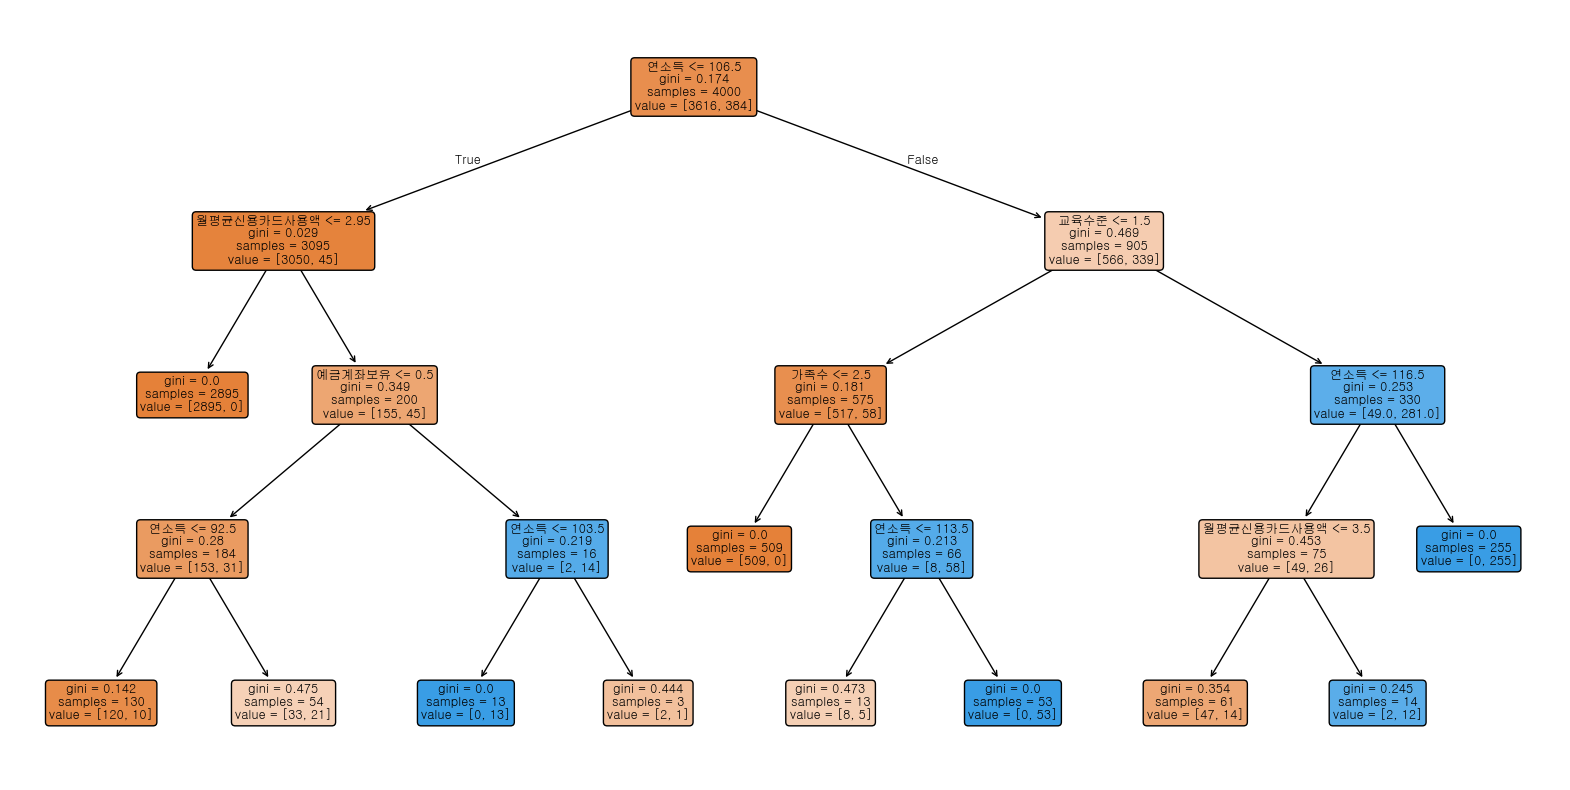

In [25]:
from pyexpat import features
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.rc('font', family='Gulim')

plt.figure(figsize=(20, 10))

plot_tree(
    model, filled=True, rounded=True, feature_names=df1.columns
)
plt.show()

In [28]:
# 특성의 중요도 확인
import pandas as pd

df2 = pd.DataFrame({'특성':df1.columns, '중요도':model.feature_importances_})
df2.sort_values(by='중요도', ascending=False)

,특성,중요도
2,연소득,0.402368
5,교육수준,0.382549
3,가족수,0.146099
4,월평균신용카드사용액,0.045191
8,예금계좌보유,0.023793
0,나이,0.000000
1,경력,0.000000
6,주택담보대출금액,0.000000
7,증권계좌보유,0.000000
9,인터넷뱅킹유무,0.000000
